# Module 1 — Live Coding Session
## Introduction to Artificial Neural Networks

**IIT Madras · Wadhwani School of AI**

---

**Session Plan (60 min):**
1. PyTorch Warm-up (~8 min)
2. XOR Problem — Why we need neural networks (~15 min)
3. Fashion-MNIST — End-to-end workflow (~15 min)
4. Q&A (~10 min)

*(The recap slides cover the theory — this notebook is all hands-on code)*

---
# Part 1: PyTorch Warm-up (~8 min)

**🎙️ Talking points:**
- *"Before we build neural networks, let's get comfortable with the building blocks — tensors."*
- *"A tensor is just a fancy word for a multi-dimensional array. Scalars, vectors, matrices — all tensors."*
- *"Everything in deep learning gets converted to tensors before the model sees it."*

In [2]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.11.0+cu130
CUDA available: False


### 1.1 Tensor Dimensions — Scalar → Vector → Matrix → Tensor

**🎙️** *"Let's build up from the simplest case. Notice how `.ndim` increases as we add dimensions."*

In [3]:
# Scalar — a single number (0 dimensions)
scalar = torch.tensor(7)
print(f"Scalar: {scalar}")
print(f"  ndim: {scalar.ndim}, shape: {scalar.shape}, value: {scalar.item()}")

print()

# Vector — a 1D array
vector = torch.tensor([1, 2, 3])
print(f"Vector: {vector}")
print(f"  ndim: {vector.ndim}, shape: {vector.shape}")

print()

# Matrix — a 2D array
MATRIX = torch.tensor([[1, 2],
                        [3, 4],
                        [5, 6]])
print(f"Matrix:\n{MATRIX}")
print(f"  ndim: {MATRIX.ndim}, shape: {MATRIX.shape}")

print()

# 3D Tensor — think: batch of matrices, or an image (H, W, C)
TENSOR = torch.rand(2, 3, 4)
print(f"3D Tensor shape: {TENSOR.shape}")
print(f"  ndim: {TENSOR.ndim}  — that's {TENSOR.shape[0]} matrices of {TENSOR.shape[1]}x{TENSOR.shape[2]}")

Scalar: 7
  ndim: 0, shape: torch.Size([]), value: 7

Vector: tensor([1, 2, 3])
  ndim: 1, shape: torch.Size([3])

Matrix:
tensor([[1, 2],
        [3, 4],
        [5, 6]])
  ndim: 2, shape: torch.Size([3, 2])

3D Tensor shape: torch.Size([2, 3, 4])
  ndim: 3  — that's 2 matrices of 3x4


### 1.2 Common Creation Methods

**🎙️** *"In practice you'll rarely type tensor values by hand. These are the patterns you'll use constantly."*

In [8]:
# Zeros and ones — used for initialization
zeros = torch.zeros(3, 4)
ones = torch.ones(3, 4)
print(f"Zeros shape: {zeros.shape}")
print(f"Ones shape:  {ones.shape}")

print()

# Random tensors — THIS is how neural network weights start
random_tensor = torch.rand(3, 4)  # uniform [0, 1)
print(f"Random tensor:\n{random_tensor}")

print()

# Image-like tensor: Height x Width x Channels
fake_image = torch.rand(224, 224, 3)
print(f"Fake image shape: {fake_image.shape}  — 224x224 RGB image")

print()

# Ranges and "like" tensors
r = torch.arange(0, 10)
print(f"Range: {r}")
print(f"Zeros like range: {torch.zeros_like(r)}")

Zeros shape: torch.Size([3, 4])
Ones shape:  torch.Size([3, 4])

Random tensor:
tensor([[0.3578, 0.2444, 0.0187, 0.9187],
        [0.4494, 0.2933, 0.3210, 0.3929],
        [0.0056, 0.3261, 0.4043, 0.5148]])

Fake image shape: torch.Size([224, 224, 3])  — 224x224 RGB image

Range: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
Zeros like range: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


### 1.3 Data Types — The \#1 Source of Bugs

**🎙️** *"If your model crashes or gives garbage results, check three things: dtype, shape, and device. 90% of bugs are one of these."*

In [9]:
# Default is float32 — the standard for neural networks
t = torch.tensor([3.0, 6.0, 9.0])
print(f"Default dtype: {t.dtype}")  # torch.float32

# Integer tensors behave differently!
t_int = torch.tensor([3, 6, 9])
print(f"Integer dtype: {t_int.dtype}")  # torch.int64

# Casting between types
t_half = t.to(torch.float16)
print(f"Half precision: {t_half.dtype}")

print()

# THE THREE DEBUGGING CHECKS:
print("=== Always check these when debugging ===")
print(f"1. dtype:  {t.dtype}")
print(f"2. shape:  {t.shape}")
print(f"3. device: {t.device}")

Default dtype: torch.float32
Integer dtype: torch.int64
Half precision: torch.float16

=== Always check these when debugging ===
1. dtype:  torch.float32
2. shape:  torch.Size([3])
3. device: cpu


### 1.4 Matrix Multiplication — The Fundamental DL Operation

**🎙️** *"Every single layer in a neural network is essentially a matrix multiply followed by an activation. This is the operation that makes everything work."*

**Rule:** Inner dimensions must match → `(m, k) @ (k, n)` → `(m, n)`

In [10]:
# Element-wise vs matrix multiply — KEY distinction
A = torch.tensor([[1, 2],
                   [3, 4]])

B = torch.tensor([[5, 6],
                   [7, 8]])

print("Element-wise multiply (A * B):")
print(A * B)

print("\nMatrix multiply (A @ B):")
print(A @ B)  # same as torch.matmul(A, B)

print("\n--- Shape rules ---")
X = torch.rand(3, 2)   # 3 samples, 2 features
W = torch.rand(2, 5)   # 2 inputs, 5 outputs (a layer!)
output = X @ W
print(f"X: {X.shape} @ W: {W.shape} → output: {output.shape}")
print("This is EXACTLY what nn.Linear(2, 5) does internally!")

Element-wise multiply (A * B):
tensor([[ 5, 12],
        [21, 32]])

Matrix multiply (A @ B):
tensor([[19, 22],
        [43, 50]])

--- Shape rules ---
X: torch.Size([3, 2]) @ W: torch.Size([2, 5]) → output: torch.Size([3, 5])
This is EXACTLY what nn.Linear(2, 5) does internally!


---
# Part 2: The XOR Problem (~15 min)

**🎙️ Talking points:**
- *"This is the most important example in this entire module. It answers: WHY do we need neural networks?"*
- *"XOR is the simplest problem that a single neuron cannot solve."*
- *"Once you understand this, you understand the fundamental motivation for deep learning."*

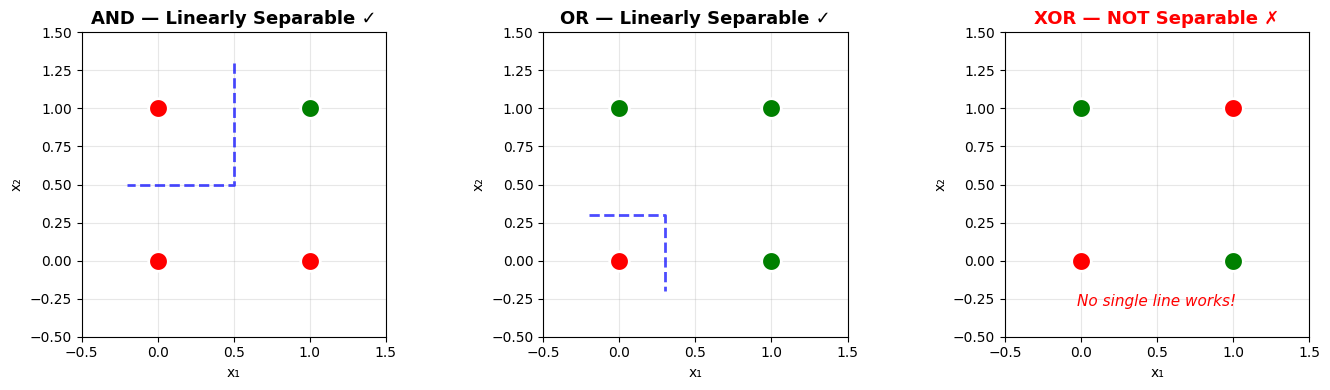

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# XOR truth table
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

# Visualize the problem
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# AND — linearly separable ✓
y_and = np.array([0, 0, 0, 1])
for i in range(4):
    axes[0].scatter(X_xor[i, 0], X_xor[i, 1], c='green' if y_and[i] == 1 else 'red',
                    s=200, edgecolors='white', linewidths=2, zorder=5)
axes[0].plot([0.5, 0.5, -0.2], [1.3, 0.5, 0.5], 'b--', alpha=0.7, linewidth=2)
axes[0].set_title('AND — Linearly Separable ✓', fontsize=13, fontweight='bold')

# OR — linearly separable ✓
y_or = np.array([0, 1, 1, 1])
for i in range(4):
    axes[1].scatter(X_xor[i, 0], X_xor[i, 1], c='green' if y_or[i] == 1 else 'red',
                    s=200, edgecolors='white', linewidths=2, zorder=5)
axes[1].plot([-0.2, 0.3, 0.3], [0.3, 0.3, -0.2], 'b--', alpha=0.7, linewidth=2)
axes[1].set_title('OR — Linearly Separable ✓', fontsize=13, fontweight='bold')

# XOR — NOT linearly separable ✗
for i in range(4):
    axes[2].scatter(X_xor[i, 0], X_xor[i, 1], c='green' if y_xor[i] == 1 else 'red',
                    s=200, edgecolors='white', linewidths=2, zorder=5)
axes[2].set_title('XOR — NOT Separable ✗', fontsize=13, fontweight='bold', color='red')
axes[2].text(0.5, -0.3, 'No single line works!', ha='center', fontsize=11, style='italic', color='red')

for ax in axes:
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel('x₁')
    ax.set_ylabel('x₂')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

### 2.1 Why a Linear Model CANNOT Solve XOR

**🎙️** *"Let me prove this isn't just hard — it's mathematically impossible with a linear model."*

A linear model computes: `f(x₁, x₂) = w₁·x₁ + w₂·x₂ + b`

From the truth table:
- f(0,0) ≈ 0 → **b ≈ 0**
- f(0,1) ≈ 1 → **w₂ + b ≈ 1** → w₂ ≈ 1
- f(1,0) ≈ 1 → **w₁ + b ≈ 1** → w₁ ≈ 1
- f(1,1) ≈ 0 → **w₁ + w₂ + b ≈ 2** ≠ 0 ← **CONTRADICTION!** 💥

*Let's watch a linear model fail:*

In [12]:
# Let's actually train a linear model and watch it fail

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Train a single neuron (logistic regression) on XOR
np.random.seed(42)
w = np.random.randn(2) * 0.5
b = 0.0
lr = 0.5

print("Training a SINGLE neuron on XOR...")
print("=" * 45)

for epoch in range(1000):
    total_loss = 0
    for i in range(4):
        # Forward
        z = np.dot(X_xor[i], w) + b
        a = sigmoid(z)
        loss = -(y_xor[i] * np.log(a + 1e-8) + (1 - y_xor[i]) * np.log(1 - a + 1e-8))
        total_loss += loss

        # Backward
        dz = a - y_xor[i]
        w -= lr * dz * X_xor[i]
        b -= lr * dz

    if epoch % 250 == 0:
        preds = sigmoid(X_xor @ w + b)
        print(f"Epoch {epoch:4d} | Loss: {total_loss:.4f} | Predictions: {np.round(preds, 2)}")

# Final results
print("\n" + "=" * 45)
print("Final predictions vs targets:")
final_preds = sigmoid(X_xor @ w + b)
for i in range(4):
    status = "✓" if round(final_preds[i]) == y_xor[i] else "✗"
    print(f"  Input: {X_xor[i]} → Predicted: {final_preds[i]:.3f} | Target: {y_xor[i]} {status}")

print("\n❌ A single neuron CANNOT learn XOR! It's stuck at ~50% accuracy.")

Training a SINGLE neuron on XOR...
Epoch    0 | Loss: 3.3855 | Predictions: [0.47 0.44 0.5  0.46]
Epoch  250 | Loss: 3.3841 | Predictions: [0.57 0.5  0.43 0.36]
Epoch  500 | Loss: 3.3841 | Predictions: [0.57 0.5  0.43 0.36]
Epoch  750 | Loss: 3.3841 | Predictions: [0.57 0.5  0.43 0.36]

Final predictions vs targets:
  Input: [0 0] → Predicted: 0.571 | Target: 0 ✗
  Input: [0 1] → Predicted: 0.500 | Target: 1 ✗
  Input: [1 0] → Predicted: 0.429 | Target: 1 ✗
  Input: [1 1] → Predicted: 0.361 | Target: 0 ✓

❌ A single neuron CANNOT learn XOR! It's stuck at ~50% accuracy.


### 2.2 The Solution: A 2-2-1 Neural Network

**🎙️** *"The fix is simple but profound: add a hidden layer. Two hidden neurons create a new feature space where XOR becomes separable."*

Architecture: **2 inputs → 2 hidden (sigmoid) → 1 output (sigmoid)**

In [13]:
class XORNetwork:
    """A simple 2-2-1 neural network built from scratch."""

    def __init__(self):
        np.random.seed(42)
        # Hidden layer (2 inputs → 2 hidden neurons)
        self.W1 = np.random.randn(2, 2) * 0.5
        self.b1 = np.zeros((1, 2))
        # Output layer (2 hidden → 1 output)
        self.W2 = np.random.randn(2, 1) * 0.5
        self.b2 = np.zeros((1, 1))

    def forward(self, X):
        # Hidden layer: linear → sigmoid
        self.z1 = X @ self.W1 + self.b1
        self.a1 = sigmoid(self.z1)
        # Output layer: linear → sigmoid
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = sigmoid(self.z2)
        return self.a2

    def backward(self, X, y, lr=1.0):
        m = X.shape[0]
        y = y.reshape(-1, 1)

        # Output layer gradients
        dz2 = self.a2 - y                              # (4, 1)
        dW2 = (self.a1.T @ dz2) / m                    # (2, 1)
        db2 = np.mean(dz2, axis=0, keepdims=True)      # (1, 1)

        # Hidden layer gradients — THIS is the chain rule!
        dz1 = (dz2 @ self.W2.T) * self.a1 * (1 - self.a1)  # sigmoid derivative!
        dW1 = (X.T @ dz1) / m                          # (2, 2)
        db1 = np.mean(dz1, axis=0, keepdims=True)      # (1, 2)

        # Update weights
        self.W2 -= lr * dW2
        self.b2 -= lr * db2
        self.W1 -= lr * dW1
        self.b1 -= lr * db1

print("XOR Network defined! Architecture: 2 → 2 → 1")

XOR Network defined! Architecture: 2 → 2 → 1


In [14]:
# Train the network!
net = XORNetwork()
losses = []

print("🚀 Training 2-2-1 Network on XOR")
print("=" * 50)

for epoch in range(5000):
    # Forward pass
    predictions = net.forward(X_xor)

    # Compute loss (binary cross-entropy)
    y_col = y_xor.reshape(-1, 1)
    loss = -np.mean(y_col * np.log(predictions + 1e-8) + (1 - y_col) * np.log(1 - predictions + 1e-8))
    losses.append(loss)

    # Backward pass + update
    net.backward(X_xor, y_xor, lr=2.0)

    if epoch % 1000 == 0:
        preds_flat = predictions.flatten()
        print(f"Epoch {epoch:4d} | Loss: {loss:.4f} | Preds: {np.round(preds_flat, 3)}")

# Final results
print("\n" + "=" * 50)
print("✅ Final predictions:")
final = net.forward(X_xor).flatten()
for i in range(4):
    status = "✓" if round(final[i]) == y_xor[i] else "✗"
    print(f"  Input: {X_xor[i]} → Predicted: {final[i]:.4f} (rounded: {round(final[i])}) | Target: {y_xor[i]} {status}")

🚀 Training 2-2-1 Network on XOR
Epoch    0 | Loss: 0.6955 | Preds: [0.471 0.463 0.469 0.462]
Epoch 1000 | Loss: 0.3526 | Preds: [0.008 0.497 0.994 0.502]
Epoch 2000 | Loss: 0.3485 | Preds: [0.002 0.499 0.998 0.501]
Epoch 3000 | Loss: 0.3477 | Preds: [0.001 0.499 0.999 0.5  ]
Epoch 4000 | Loss: 0.3474 | Preds: [0.001 0.5   0.999 0.5  ]

✅ Final predictions:
  Input: [0 0] → Predicted: 0.0007 (rounded: 0) | Target: 0 ✓
  Input: [0 1] → Predicted: 0.4997 (rounded: 0) | Target: 1 ✗
  Input: [1 0] → Predicted: 0.9994 (rounded: 1) | Target: 1 ✓
  Input: [1 1] → Predicted: 0.5003 (rounded: 1) | Target: 0 ✗


### 2.3 What Did the Hidden Layer Learn?

**🎙️** *"The magic of the hidden layer: it transforms the input space into a new representation where XOR becomes linearly separable. Let's see exactly what it learned."*

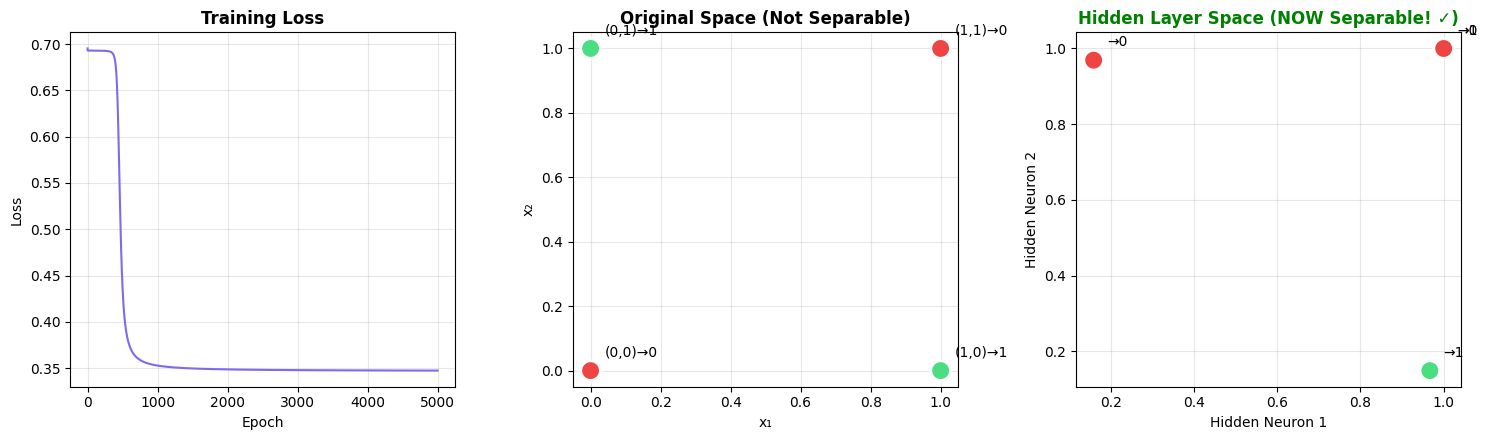


💡 Key Insight: The hidden layer REMAPS the inputs into a new space
   where a simple line CAN separate the two classes!
   This is what 'representation learning' means.


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Plot 1: Loss curve
axes[0].plot(losses, color='#7C6AEF', linewidth=1.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot 2: Original space (not separable)
colors = ['#EF4444' if y == 0 else '#4ADE80' for y in y_xor]
axes[1].scatter(X_xor[:, 0], X_xor[:, 1], c=colors, s=200, edgecolors='white', linewidths=2, zorder=5)
for i in range(4):
    axes[1].annotate(f"({X_xor[i,0]},{X_xor[i,1]})→{y_xor[i]}",
                     (X_xor[i,0], X_xor[i,1]), textcoords="offset points",
                     xytext=(10, 10), fontsize=10)
axes[1].set_title('Original Space (Not Separable)', fontweight='bold')
axes[1].set_xlabel('x₁')
axes[1].set_ylabel('x₂')
axes[1].grid(True, alpha=0.3)

# Plot 3: Hidden layer representation (NOW separable!)
hidden_outputs = net.a1  # activations from hidden layer
axes[2].scatter(hidden_outputs[:, 0], hidden_outputs[:, 1], c=colors, s=200,
                edgecolors='white', linewidths=2, zorder=5)
for i in range(4):
    axes[2].annotate(f"→{y_xor[i]}",
                     (hidden_outputs[i, 0], hidden_outputs[i, 1]),
                     textcoords="offset points", xytext=(10, 10), fontsize=10)
axes[2].set_title('Hidden Layer Space (NOW Separable! ✓)', fontweight='bold', color='green')
axes[2].set_xlabel('Hidden Neuron 1')
axes[2].set_ylabel('Hidden Neuron 2')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Key Insight: The hidden layer REMAPS the inputs into a new space")
print("   where a simple line CAN separate the two classes!")
print("   This is what 'representation learning' means.")

### 2.4 Quick Bonus: XOR in PyTorch (3 lines!)

**🎙️** *"We built it from scratch to understand. In practice, PyTorch handles all of this for you:"*

In [26]:
import torch
import torch.nn as nn

# Same 2-2-1 architecture, but in PyTorch
torch.manual_seed(42)

model_xor = nn.Sequential(
    nn.Linear(2, 2),    # hidden layer
    nn.Sigmoid(),
    nn.Linear(2, 1),    # output layer
    nn.Sigmoid()
)

X_t = torch.tensor(X_xor, dtype=torch.float32)
y_t = torch.tensor(y_xor, dtype=torch.float32).reshape(-1, 1)

optimizer = torch.optim.SGD(model_xor.parameters(), lr=2.0)
loss_fn = nn.BCELoss()

# Train with the EXACT same 5-step loop
for epoch in range(5000):
    pred = model_xor(X_t)           # 1. Forward
    loss = loss_fn(pred, y_t)       # 2. Loss
    optimizer.zero_grad()            # 3. Zero grads
    loss.backward()                  # 4. Backward
    optimizer.step()                 # 5. Update

# Check results
with torch.inference_mode():
    result = model_xor(X_t)
    print("PyTorch XOR results:")
    for i in range(4):
        print(f"  {X_xor[i]} → {result[i].item():.4f} (target: {y_xor[i]})")

PyTorch XOR results:
  [0 0] → 0.0014 (target: 0)
  [0 1] → 0.9990 (target: 1)
  [1 0] → 0.9990 (target: 1)
  [1 1] → 0.0010 (target: 0)


---
# Part 3: Fashion-MNIST End-to-End (~15 min)

**🎙️ Talking points:**
- *"Now let's do the real thing — a 10-class image classification problem."*
- *"Fashion-MNIST: 70,000 grayscale images of clothing items."*
- *"Same training loop pattern — forward, loss, zero_grad, backward, step. It doesn't change."*

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time

### 3.1 Data Loading

**🎙️** *"Two transforms: ToTensor converts pixels from [0,255] to [0,1] and flips HWC to CHW. Normalize centers the data around 0, which helps training stability."*

In [18]:
# Define transforms
transform = transforms.Compose([
    transforms.ToTensor(),                     # [0,255] → [0,1], HWC → CHW
    transforms.Normalize((0.5,), (0.5,))       # center to [-1, 1]
])

# Download and load datasets
train_data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# DataLoaders — handles batching and shuffling
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# Class names for visualization
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Training samples: {len(train_data):,}")
print(f"Test samples:     {len(test_data):,}")
print(f"Image shape:      {train_data[0][0].shape}  (channels, height, width)")
print(f"Number of classes: {len(class_names)}")
print(f"Batches per epoch: {len(train_loader)}")

100%|██████████| 26.4M/26.4M [00:03<00:00, 8.69MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 137kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.55MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.4MB/s]

Training samples: 60,000
Test samples:     10,000
Image shape:      torch.Size([1, 28, 28])  (channels, height, width)
Number of classes: 10
Batches per epoch: 938


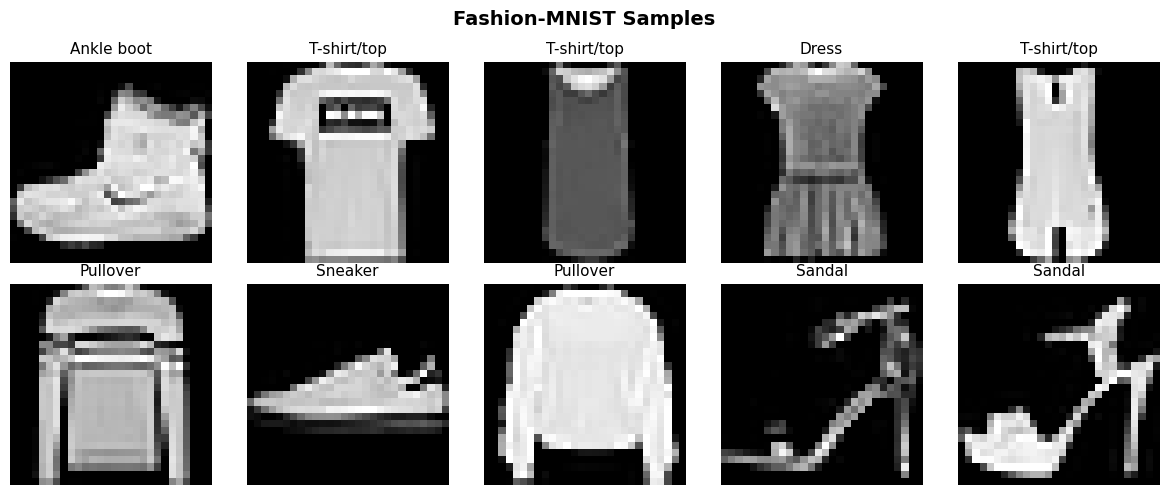

In [19]:
# Visualize some samples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    image, label = train_data[i]
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(class_names[label], fontsize=11)
    ax.axis('off')
plt.suptitle('Fashion-MNIST Samples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.2 Model Architecture

**🎙️** *"We're building a Multi-Layer Perceptron (MLP). We flatten the 28x28 image into 784 numbers, then pass through two hidden layers. Notice: NO softmax in forward() — CrossEntropyLoss handles it."*

Architecture: **784 → 128 → 64 → 10**

In [20]:
class FashionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()            # 28x28 → 784
        self.hidden1 = nn.Linear(784, 128)     # first hidden layer
        self.hidden2 = nn.Linear(128, 64)      # second hidden layer
        self.output = nn.Linear(64, 10)        # 10 classes
        self.relu = nn.ReLU()                  # activation for hidden layers
        self.dropout = nn.Dropout(0.2)         # regularization

    def forward(self, x):
        x = self.flatten(x)
        x = self.dropout(self.relu(self.hidden1(x)))
        x = self.dropout(self.relu(self.hidden2(x)))
        x = self.output(x)                     # raw logits — NO softmax!
        return x

# Create model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FashionMLP().to(device)
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

FashionMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (hidden1): Linear(in_features=784, out_features=128, bias=True)
  (hidden2): Linear(in_features=128, out_features=64, bias=True)
  (output): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
)

Total parameters: 109,386


### 3.3 Training Configuration

**🎙️** *"Three choices: CrossEntropyLoss for multi-class, Adam optimizer (our go-to default), and we'll train for 10 epochs."*

In [21]:
# Loss and optimizer
loss_fn = nn.CrossEntropyLoss()                            # multi-class classification
optimizer = optim.Adam(model.parameters(), lr=0.001)       # Adam — reliable default

num_epochs = 10
print(f"Loss: CrossEntropyLoss (handles softmax internally)")
print(f"Optimizer: Adam (lr=0.001)")
print(f"Epochs: {num_epochs}")

Loss: CrossEntropyLoss (handles softmax internally)
Optimizer: Adam (lr=0.001)
Epochs: 10


### 3.4 The Training Loop

**🎙️** *"Here's the exact same 5-step pattern from the slides. Forward → Loss → Zero Grad → Backward → Step. The only new thing is we're looping over batches from the DataLoader."*

In [22]:
train_losses = []
test_losses = []
test_accs = []

start_time = time.time()

for epoch in range(num_epochs):
    # ===== TRAINING =====
    model.train()                              # enable dropout
    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        pred = model(batch_X)                  # 1. Forward pass
        loss = loss_fn(pred, batch_y)           # 2. Compute loss
        optimizer.zero_grad()                   # 3. Zero gradients
        loss.backward()                         # 4. Backpropagation
        optimizer.step()                        # 5. Update weights

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ===== EVALUATION =====
    model.eval()                               # disable dropout
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.inference_mode():               # no gradient tracking
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            pred = model(batch_X)
            test_loss += loss_fn(pred, batch_y).item()
            correct += (pred.argmax(dim=1) == batch_y).sum().item()
            total += batch_y.size(0)

    avg_test_loss = test_loss / len(test_loader)
    accuracy = correct / total
    test_losses.append(avg_test_loss)
    test_accs.append(accuracy)

    print(f"Epoch {epoch+1:2d}/{num_epochs} | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Test Loss: {avg_test_loss:.4f} | "
          f"Test Acc: {accuracy:.1%}")

elapsed = time.time() - start_time
print(f"\n✅ Training complete in {elapsed:.1f}s")
print(f"   Final test accuracy: {test_accs[-1]:.1%}")

Epoch  1/10 | Train Loss: 0.5889 | Test Loss: 0.4468 | Test Acc: 84.0%
Epoch  2/10 | Train Loss: 0.4316 | Test Loss: 0.4022 | Test Acc: 85.4%
Epoch  3/10 | Train Loss: 0.3962 | Test Loss: 0.3752 | Test Acc: 86.3%
Epoch  4/10 | Train Loss: 0.3743 | Test Loss: 0.3774 | Test Acc: 85.9%
Epoch  5/10 | Train Loss: 0.3590 | Test Loss: 0.3706 | Test Acc: 86.8%
Epoch  6/10 | Train Loss: 0.3438 | Test Loss: 0.3557 | Test Acc: 87.0%
Epoch  7/10 | Train Loss: 0.3377 | Test Loss: 0.3538 | Test Acc: 87.0%
Epoch  8/10 | Train Loss: 0.3251 | Test Loss: 0.3479 | Test Acc: 87.5%
Epoch  9/10 | Train Loss: 0.3162 | Test Loss: 0.3611 | Test Acc: 86.8%
Epoch 10/10 | Train Loss: 0.3101 | Test Loss: 0.3446 | Test Acc: 88.0%

✅ Training complete in 199.6s
   Final test accuracy: 88.0%


### 3.5 Results Visualization

**🎙️** *"Let's see how the model did — loss curves and some actual predictions."*

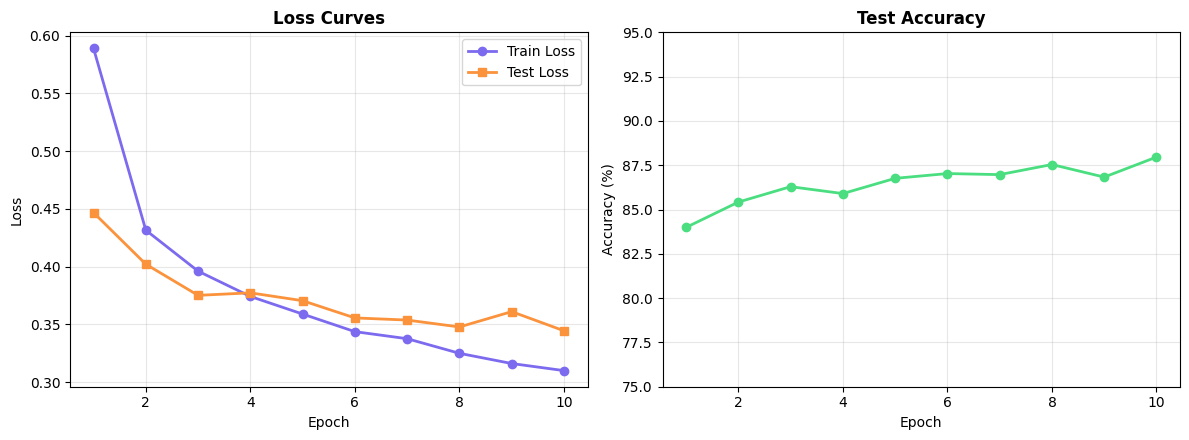

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Loss curves
epochs_range = range(1, num_epochs + 1)
axes[0].plot(epochs_range, train_losses, 'o-', label='Train Loss', color='#7C6AEF', linewidth=2)
axes[0].plot(epochs_range, test_losses, 's-', label='Test Loss', color='#FB923C', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curves', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(epochs_range, [a * 100 for a in test_accs], 'o-', color='#4ADE80', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Test Accuracy', fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(75, 95)

plt.tight_layout()
plt.show()

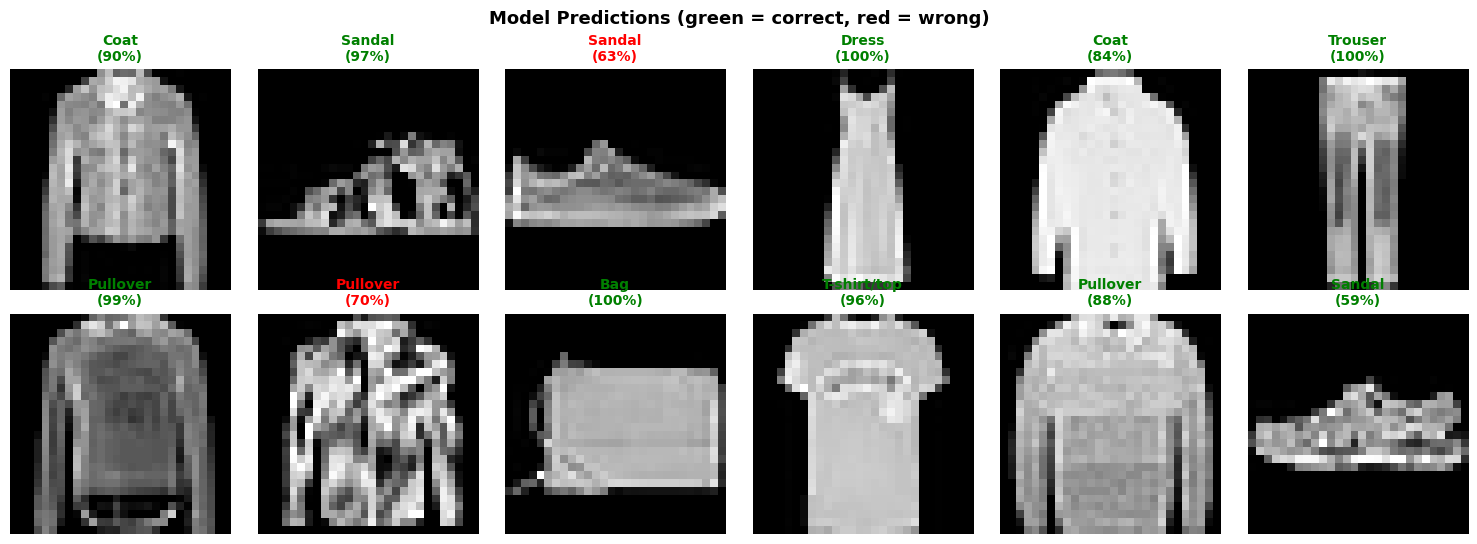

In [24]:
# Show predictions on test images
model.eval()
fig, axes = plt.subplots(2, 6, figsize=(15, 5.5))

with torch.inference_mode():
    for i, ax in enumerate(axes.flat):
        image, true_label = test_data[i + 10]  # skip first few for variety

        # Get prediction
        logits = model(image.unsqueeze(0).to(device))
        probs = torch.softmax(logits, dim=1)   # NOW we apply softmax for probabilities
        pred_label = probs.argmax(dim=1).item()
        confidence = probs.max().item()

        # Display
        ax.imshow(image.squeeze(), cmap='gray')
        color = 'green' if pred_label == true_label else 'red'
        ax.set_title(f"{class_names[pred_label]}\n({confidence:.0%})",
                     fontsize=10, color=color, fontweight='bold')
        ax.axis('off')

plt.suptitle('Model Predictions (green = correct, red = wrong)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.6 Model Saving

**🎙️** *"Always save your trained model. state_dict() saves just the learned weights — that's the standard approach."*

In [25]:
# Save the model
torch.save(model.state_dict(), 'fashion_mnist_model.pth')
print("✅ Model saved to fashion_mnist_model.pth")

# How to load it back:
# loaded_model = FashionMLP()
# loaded_model.load_state_dict(torch.load('fashion_mnist_model.pth'))
# loaded_model.eval()

✅ Model saved to fashion_mnist_model.pth


---
# Recap & Key Takeaways

**🎙️** *"Let me summarize the three things I want you to take away from today:"*

### 1. The Training Loop is Always the Same
```python
pred = model(X)           # Forward
loss = loss_fn(pred, y)   # Loss
optimizer.zero_grad()     # Zero gradients
loss.backward()           # Backprop
optimizer.step()          # Update
```
Whether it's XOR or Fashion-MNIST or GPT — same 5 steps.

### 2. Hidden Layers Learn Representations
XOR proved it: a single neuron can't solve non-linear problems. Hidden layers transform the input into a space where the problem becomes solvable.

### 3. PyTorch Pattern
- Subclass `nn.Module`, define layers in `__init__`, computation in `forward()`
- Use `model.train()` for training, `model.eval()` + `torch.inference_mode()` for testing
- Output **raw logits** — let the loss function handle sigmoid/softmax

---
*Questions?*